<a href="https://colab.research.google.com/github/MDAYAN0511/-internSpark-Intership-project-3-/blob/main/instagram_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [18]:
users = pd.read_csv("/content/users.csv")
photos = pd.read_csv("/content/photos.csv")
likes = pd.read_csv("/content/likes.csv")
comments = pd.read_csv("/content/comments.csv")
tags = pd.read_csv("/content/tags.csv")
photo_tags = pd.read_csv("/content/photo_tags.csv")
follows = pd.read_csv("/content/follows.csv")

print("Users:", users.shape)
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)


Users: (100, 6)
Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)


In [19]:
datasets = {
    "Users": users,
    "Photos": photos,
    "Likes": likes,
    "Comments": comments,
    "Tags": tags,
    "Photo Tags": photo_tags,
    "Follows": follows
}

for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())
    print("\nSummary:")
    print(df.describe(include="all"))


Users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               100 non-null    int64 
 1   name             100 non-null    object
 2   created time     100 non-null    object
 3   private/public   100 non-null    object
 4   post count       100 non-null    int64 
 5   Verified status  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB
None

Missing Values:
id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64

Summary:
                id           name      created time private/public  \
count   100.000000            100               100            100   
unique         NaN            100               100              2   
top            NaN  Kenton_Kirlin  16-02-2017 18:22            yes   
freq           NaN           

In [20]:
photos["created dat"] = pd.to_datetime(
    photos["created dat"],
    errors="coerce"
)

likes["created time"] = pd.to_datetime(
    likes["created time"],
    dayfirst=True,
    errors="coerce"
)

comments["created Timestamp"] = pd.to_datetime(
    comments["created Timestamp"],
    errors="coerce"
)


/tmp/ipykernel_2111/1576258950.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  photos["created dat"] = pd.to_datetime(
/tmp/ipykernel_2111/1576258950.py:12: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  comments["created Timestamp"] = pd.to_datetime(


In [21]:
followers = follows.groupby("followee ")["follower"].count().reset_index()

followers.columns = ["user_id", "followers"]

In [22]:
likes_per_photo = likes.groupby("photo")["user "].count().reset_index()
likes_per_photo.columns = ["photo_id", "likes"]

In [23]:
comments_per_photo = comments.groupby("Photo id")["id"].count().reset_index()
comments_per_photo.columns = ["photo_id", "comments"]


In [24]:
engagement = photos.merge(
    likes_per_photo,
    left_on="id",
    right_on="photo_id",
    how="left"
)

engagement = engagement.merge(
    comments_per_photo,
    left_on="id",
    right_on="photo_id",
    how="left"
)

engagement = engagement.merge(
    followers,
    left_on="user ID",
    right_on="user_id",
    how="left"
)

engagement["likes"] = engagement["likes"].fillna(0)
engagement["comments"] = engagement["comments"].fillna(0)
engagement["followers"] = engagement["followers"].fillna(1)


In [25]:
engagement["engagement_rate"] = (
    (engagement["likes"] + engagement["comments"])
    / engagement["followers"]
)

engagement["likes_per_follower"] = (
    engagement["likes"] / engagement["followers"]
)

engagement["comments_per_follower"] = (
    engagement["comments"] / engagement["followers"]
)

print("\nTop Engagement Posts")
print(
    engagement[
        ["id","photo type","likes","comments","followers",
         "engagement_rate"]
    ].sort_values(
        "engagement_rate",
        ascending=False
    ).head(10)
)



Top Engagement Posts
      id photo type  likes  comments  followers  engagement_rate
12    13      photo     40        39         76         1.039474
144  145      video     48        27         76         0.986842
146  147      photo     41        34         76         0.986842
117  118      photo     39        35         76         0.973684
226  227      photo     39        35         76         0.973684
224  225      video     37        36         76         0.960526
195  196      photo     38        35         76         0.960526
122  123      photo     42        31         76         0.960526
126  127      photo     43        30         76         0.960526
96    97      photo     40        32         76         0.947368


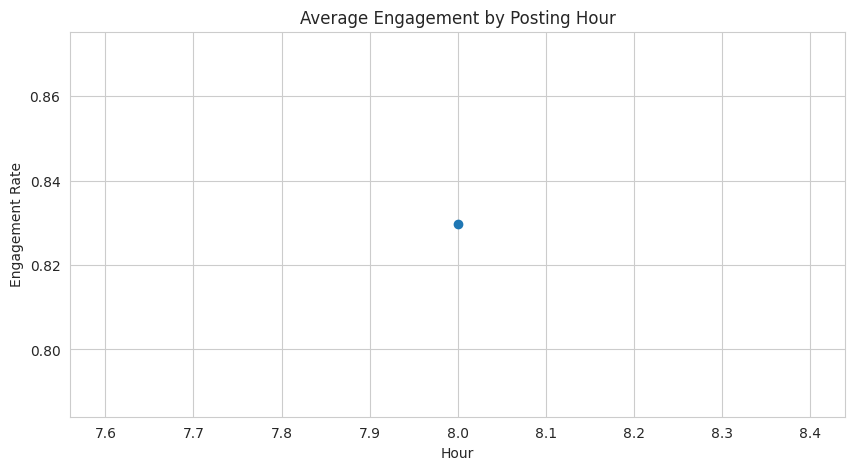

In [26]:
engagement["hour"] = engagement["created dat"].dt.hour
engagement["day"] = engagement["created dat"].dt.day_name()

hourly = engagement.groupby("hour")["engagement_rate"].mean()

plt.figure(figsize=(10,5))
hourly.plot(marker="o")
plt.title("Average Engagement by Posting Hour")
plt.xlabel("Hour")
plt.ylabel("Engagement Rate")
plt.show()

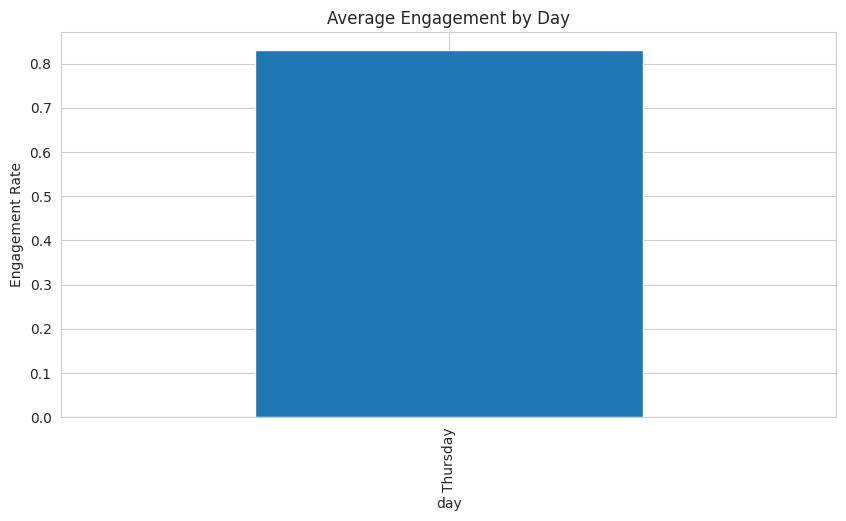

In [27]:
daily = engagement.groupby("day")["engagement_rate"].mean()

plt.figure(figsize=(10,5))
daily.sort_values().plot(kind="bar")
plt.title("Average Engagement by Day")
plt.ylabel("Engagement Rate")
plt.show()

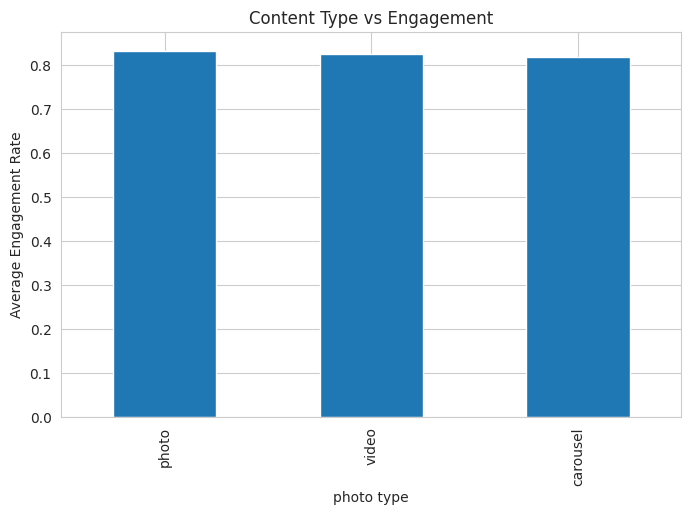


Content Type Performance
photo type
photo       0.833777
video       0.826890
carousel    0.819945
Name: engagement_rate, dtype: float64


In [28]:
content_perf = (
    engagement.groupby("photo type")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
content_perf.plot(kind="bar")
plt.title("Content Type vs Engagement")
plt.ylabel("Average Engagement Rate")
plt.show()

print("\nContent Type Performance")
print(content_perf)


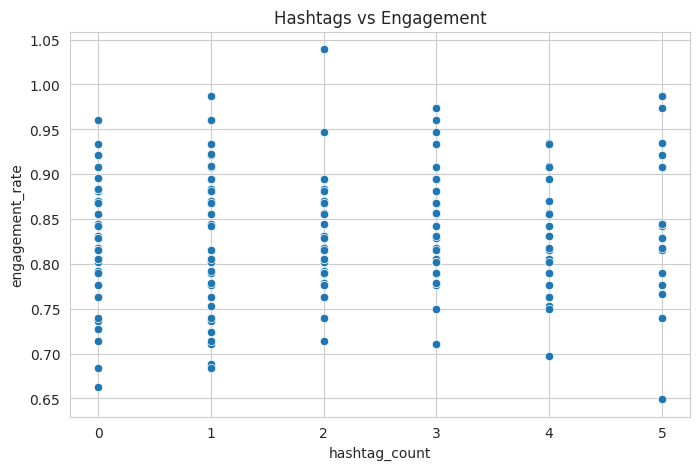

In [29]:
photo_tag_count = (
    photo_tags.groupby("photo")["tag ID"]
    .count()
    .reset_index()
)

photo_tag_count.columns = ["photo_id","hashtag_count"]

engagement = engagement.merge(
    photo_tag_count,
    left_on="id",
    right_on="photo_id",
    how="left"
)

engagement["hashtag_count"] = (
    engagement["hashtag_count"]
    .fillna(0)
)

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=engagement,
    x="hashtag_count",
    y="engagement_rate"
)
plt.title("Hashtags vs Engagement")
plt.show()

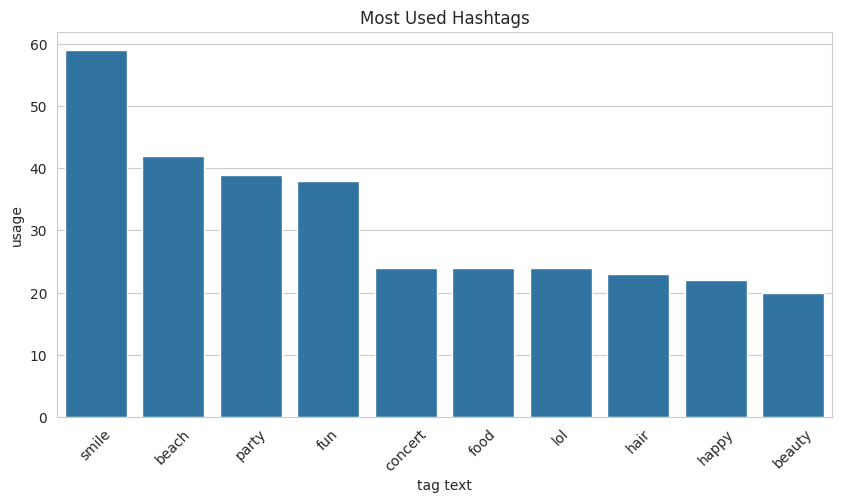

In [30]:
top_tags = (
    photo_tags["tag ID"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_tags.columns = ["tag_id","usage"]

top_tags = top_tags.merge(
    tags,
    left_on="tag_id",
    right_on="id"
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_tags,
    x="tag text",
    y="usage"
)
plt.xticks(rotation=45)
plt.title("Most Used Hashtags")
plt.show()

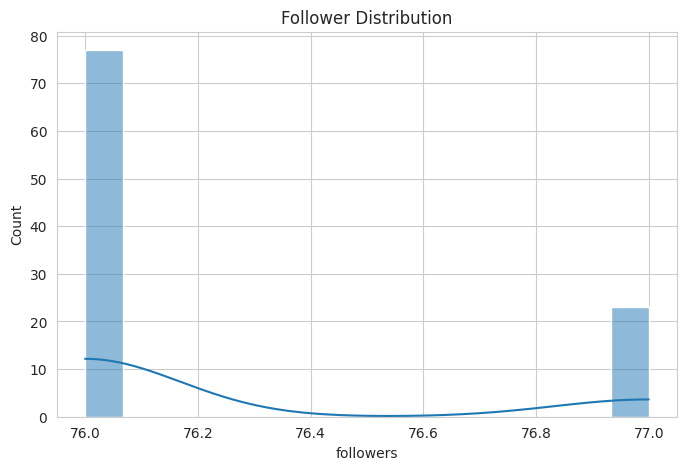

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(
    followers["followers"],
    bins=15,
    kde=True
)
plt.title("Follower Distribution")
plt.show()


In [32]:
user_engagement = (
    engagement.groupby("user ID")["engagement_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("\nTop Performing Users")
print(user_engagement.head(10))


Top Performing Users
user ID
55    0.986842
73    0.960526
48    0.934211
22    0.921053
94    0.894737
87    0.894737
69    0.894737
18    0.881579
43    0.878947
52    0.876316
Name: engagement_rate, dtype: float64


In [33]:
best_hour = hourly.idxmax()
best_day = daily.idxmax()

print("\n" + "="*60)
print("RECOMMENDED CONTENT CALENDAR")
print("="*60)

print(f"""
Best Day to Post : {best_day}
Best Time to Post: {best_hour}:00

Suggested Weekly Schedule

Monday    - Educational Post
Tuesday   - Industry Tips
Wednesday - Product Showcase
Thursday  - Behind-the-scenes
Friday    - Success Story / Case Study
Saturday  - Poll / Interactive Content
Sunday    - Weekly Recap

Use 5-10 relevant hashtags.
Focus on content types with highest engagement.
""")


RECOMMENDED CONTENT CALENDAR

Best Day to Post : Thursday
Best Time to Post: 8:00

Suggested Weekly Schedule

Monday    - Educational Post
Tuesday   - Industry Tips
Wednesday - Product Showcase
Thursday  - Behind-the-scenes
Friday    - Success Story / Case Study
Saturday  - Poll / Interactive Content
Sunday    - Weekly Recap

Use 5-10 relevant hashtags.
Focus on content types with highest engagement.



In [34]:
print("\n" + "="*60)
print("5 STRATEGIES TO INCREASE ENGAGEMENT")
print("="*60)

strategies = [
    "Post during highest-engagement hours identified in analysis.",
    "Increase use of high-performing hashtags.",
    "Prioritize the content type with highest engagement rate.",
    "Encourage comments through questions, polls and CTA captions.",
    "Collaborate with influencers and industry partners to improve follower growth."
]

for i, s in enumerate(strategies, 1):
    print(f"{i}. {s}")


5 STRATEGIES TO INCREASE ENGAGEMENT
1. Post during highest-engagement hours identified in analysis.
2. Increase use of high-performing hashtags.
3. Prioritize the content type with highest engagement rate.
4. Encourage comments through questions, polls and CTA captions.
5. Collaborate with influencers and industry partners to improve follower growth.
